In [13]:
import pandas as pd
from sklearn import tree
from sklearn import metrics

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
matplotlib.rc('xtick', labelsize=20)
matplotlib.rc('ytick', labelsize=20)

%matplotlib inline

In [3]:
df = pd.read_csv("winequality-red.csv")

In [4]:
quality_mapping = {
    3: 0,
    4: 1,
    5: 2,
    6: 3,
    7: 4,
    8: 5 
}

df.loc[:, "quality"] = df.quality.map(quality_mapping)

In [5]:
df = df.sample(frac=1).reset_index(drop=True)

df_train = df.head(1000)

df_test = df.tail(599)

In [ ]:
cols = ['fixed acidity', 
        'volatile acidity', 
        'citric acid', 
        'residual sugar',
        'chlorides', 
        'free sulfur dioxide',
        'total sulfur dioxide', 
        'density',
        'pH',
        'sulphates',
        'alcohol']

DecisionTreeClassifier(max_depth=3)

In [10]:
train_accuracies = [0.5]
test_accuracies = [0.5]

In [15]:
for depth in range(1, 25):
    clf = tree.DecisionTreeClassifier(max_depth=depth)

    clf.fit(df_train[cols], df_train.quality)

    train_predictions = clf.predict(df_train[cols])

    test_predictions = clf.predict(df_test[cols])

    train_accuracy = metrics.accuracy_score(
        df_train.quality, train_predictions
    )

    test_accuracy = metrics.accuracy_score(
        df_test.quality, test_predictions
    )

    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)


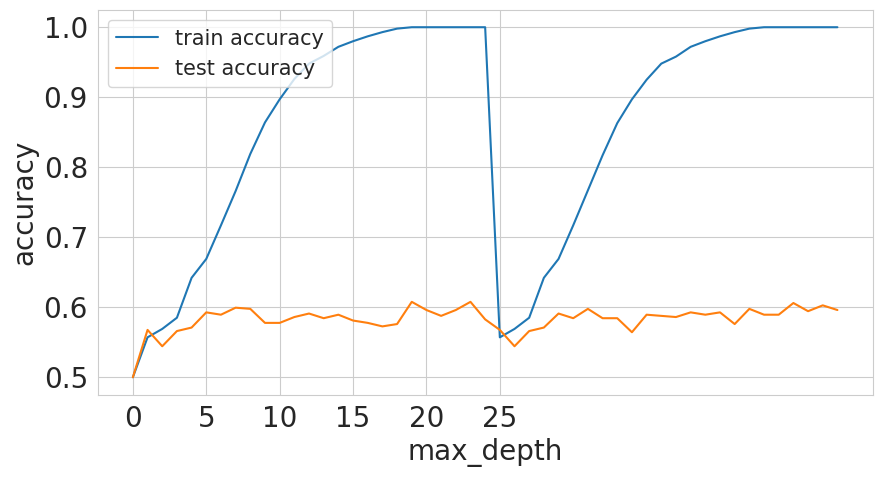

In [16]:
plt.figure(figsize=(10, 5))
sns.set_style("whitegrid")
plt.plot(train_accuracies, label="train accuracy")
plt.plot(test_accuracies, label="test accuracy")
plt.legend(loc="upper left", prop={'size':15})
plt.xticks(range(0, 26, 5))
plt.xlabel("max_depth", size=20)
plt.ylabel("accuracy", size=20)
plt.show()